# Microsoft Stock Forecasting: Data Preparation and Preprocessing

## Purpose

This notebook prepares Microsoft (`MSFT`) daily stock data for a supervised deep learning forecasting task. MSFT is used because it is a large, liquid technology stock with a long public price history, which gives enough daily observations for sequence models.

The project target is the next trading day's adjusted Close price. Each model receives a 60-trading-day history of five OHLCV inputs:

- `Open`: first traded price of the day
- `High`: highest price of the day
- `Low`: lowest price of the day
- `Close`: adjusted closing price used as the target series
- `Volume`: number of shares traded

## Link to the project workflow

This is the Data Understanding and Data Preparation stage of the CA2 workflow. It downloads the data, checks the time-series structure, creates chronological splits, scales values without leakage, builds 60-day windows, and saves the arrays used later by Notebook 02, Notebook 03, and Notebook 04.


## Dataset source and date range

The dataset is downloaded from Yahoo Finance using `yfinance` for ticker `MSFT` at daily granularity.

Project period: **2010-01-01 to 2026-04-23**.

`yfinance` normally treats the `end` argument as exclusive, so this notebook requests `END_DATE = "2026-04-24"` to include trading data through **2026-04-23**.

This notebook uses `auto_adjust=True`. With this setting, Yahoo Finance adjusts price fields for corporate actions such as stock splits and dividends. This keeps the long-term price series more consistent for modelling. The target is therefore the adjusted next-day Close, not the raw unadjusted closing price.


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yfinance as yf
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Project constants
TICKER = "MSFT"
START_DATE = "2010-01-01"
END_DATE = "2026-04-24"  # yfinance end date is exclusive; includes data through 2026-04-23
PROJECT_END_DATE = "2026-04-23"
PROJECT_PERIOD_LABEL = f"{START_DATE} to {PROJECT_END_DATE}"

FEATURE_COLS = ["Open", "High", "Low", "Close", "Volume"]
TARGET_COL = "Close"
WINDOW_SIZE = 60

DATA_DIR = Path("../data")
MODELS_DIR = Path("../models")
PLOTS_DIR = Path("../outputs/plots")
TABLES_DIR = Path("../outputs/tables")

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

print("Libraries imported successfully.")
print(f"Ticker: {TICKER}")
print(f"Project period: {PROJECT_PERIOD_LABEL}")
print(f"yfinance request: start={START_DATE}, end={END_DATE} (exclusive end)")


Libraries imported successfully.
Ticker: MSFT
Project period: 2010-01-01 to 2026-04-23
yfinance request: start=2010-01-01, end=2026-04-24 (exclusive end)


## Data cleaning and preprocessing

The raw Yahoo Finance download is standardised to the five project input features, sorted chronologically, checked for duplicate dates, and cleaned by removing rows with missing values. The first actual trading row may be after 2010-01-01 because markets were closed on that date.


In [2]:
# Download MSFT daily data from Yahoo Finance.
raw_df = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
)

if raw_df.empty:
    raise ValueError("No data was downloaded from yfinance. Check ticker, date range, or network access.")

# yfinance can return a MultiIndex even for a single ticker depending on version/settings.
if isinstance(raw_df.columns, pd.MultiIndex):
    if set(FEATURE_COLS).issubset(raw_df.columns.get_level_values(0)):
        raw_df.columns = raw_df.columns.get_level_values(0)
    elif set(FEATURE_COLS).issubset(raw_df.columns.get_level_values(1)):
        raw_df.columns = raw_df.columns.get_level_values(1)
    else:
        raise ValueError(f"Could not find required OHLCV columns in downloaded data: {raw_df.columns}")

raw_df.columns.name = None
missing_required = set(FEATURE_COLS) - set(raw_df.columns)
if missing_required:
    raise ValueError(f"Downloaded data is missing required columns: {sorted(missing_required)}")

missing_before_cleaning = raw_df[FEATURE_COLS].isna().sum()

df = raw_df[FEATURE_COLS].copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

if df.index.has_duplicates:
    duplicate_count = int(df.index.duplicated().sum())
    print(f"Duplicate date rows found and removed: {duplicate_count}")
    df = df[~df.index.duplicated(keep="first")]

df = df.dropna()

if not df.index.is_monotonic_increasing:
    raise AssertionError("The cleaned dataset is not sorted chronologically.")

print(f"Project period: {PROJECT_PERIOD_LABEL}")
print(f"Cleaned dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Confirmed trading date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Requested final included date: {PROJECT_END_DATE}")
print(f"Input features: {FEATURE_COLS}")
print(f"Prediction target: next trading-day adjusted {TARGET_COL}")


Project period: 2010-01-01 to 2026-04-23
Cleaned dataset shape: 4,101 rows x 5 columns
Confirmed trading date range: 2010-01-04 to 2026-04-23
Requested final included date: 2026-04-23
Input features: ['Open', 'High', 'Low', 'Close', 'Volume']
Prediction target: next trading-day adjusted Close


### Cleaning output interpretation

The output above should confirm the cleaned row count, the actual trading-date range, and the five required OHLCV columns. These checks matter because all later models assume a complete chronological daily series with `Close` at the same feature position.


## Exploratory data analysis

This section documents the size, date coverage, missingness, descriptive statistics, price trend, split boundaries, feature correlations, and daily return behaviour of the MSFT dataset before modelling.


### Dataset shape, first rows, and last rows

These checks confirm the downloaded daily OHLCV structure and show the beginning and end of the project period used for modelling.


In [3]:
print(f"Dataset shape: {df.shape}")
print(f"Project period: {PROJECT_PERIOD_LABEL}")
print(f"Confirmed trading date range: {df.index.min().date()} to {df.index.max().date()}")

print("First five rows:")
display(df.head())

print("Last five rows:")
display(df.tail())


Dataset shape: (4101, 5)
Project period: 2010-01-01 to 2026-04-23
Confirmed trading date range: 2010-01-04 to 2026-04-23
First five rows:


,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,22.831324,23.189228,22.808954,23.077383,38409100
2010-01-05,23.002820,23.189229,22.846236,23.084839,49749600
2010-01-06,23.025186,23.174313,22.756758,22.943167,58182400
2010-01-07,22.838774,22.890970,22.510696,22.704561,50559700
2010-01-08,22.577810,23.025190,22.547984,22.861151,51197400


Last five rows:


,Open,High,Low,Close,Volume
Date,,,,,
2026-04-17,424.820007,431.579987,420.690002,422.790009,48568200
2026-04-20,421.149994,423.329987,416.299988,418.070007,27582200
2026-04-21,420.239990,427.179993,417.200012,424.160004,32048500
2026-04-22,426.190002,433.700012,423.670013,432.920013,29378200
2026-04-23,419.890015,423.660004,411.410004,415.750000,38151200


### Missing values

Missing values are checked before and after cleaning. Any rows with missing values in the required OHLCV fields are removed before splitting and scaling.


In [4]:
missing_table = pd.DataFrame(
    {
        "missing_before_cleaning": missing_before_cleaning,
        "missing_after_cleaning": df[FEATURE_COLS].isna().sum(),
    }
)
missing_table["missing_after_cleaning_pct"] = (missing_table["missing_after_cleaning"] / len(df) * 100).round(4)

display(missing_table)
assert missing_table["missing_after_cleaning"].sum() == 0, "Missing values remain after cleaning."


,missing_before_cleaning,missing_after_cleaning,missing_after_cleaning_pct
Open,0,0,0.0
High,0,0,0.0
Low,0,0,0.0
Close,0,0,0.0
Volume,0,0,0.0


### Descriptive statistics

The summary statistics below describe the five model input features over the project period 2010-01-01 to 2026-04-23.


In [5]:
descriptive_stats = df[FEATURE_COLS].describe().T

display(descriptive_stats)


,count,mean,std,min,25%,50%,75%,max
Open,4101.0,1.542284e+02,1.482466e+02,1.737526e+01,3.117842e+01,8.485334e+01,2.607952e+02,5.520232e+02
High,4101.0,1.556582e+02,1.495224e+02,1.754834e+01,3.140025e+01,8.587883e+01,2.648347e+02,5.522420e+02
Low,4101.0,1.527133e+02,1.468354e+02,1.710436e+01,3.095132e+01,8.396321e+01,2.591042e+02,5.385307e+02
Close,4101.0,1.542499e+02,1.482253e+02,1.731505e+01,3.120845e+01,8.472488e+01,2.610258e+02,5.398253e+02
Volume,4101.0,3.530292e+07,2.048599e+07,5.855900e+06,2.208470e+07,2.947670e+07,4.313480e+07,3.193179e+08


### Adjusted Close price over time

The plot shows the adjusted MSFT Close price used as the forecasting target. The long-term upward trend and changing volatility indicate why chronological validation is required.


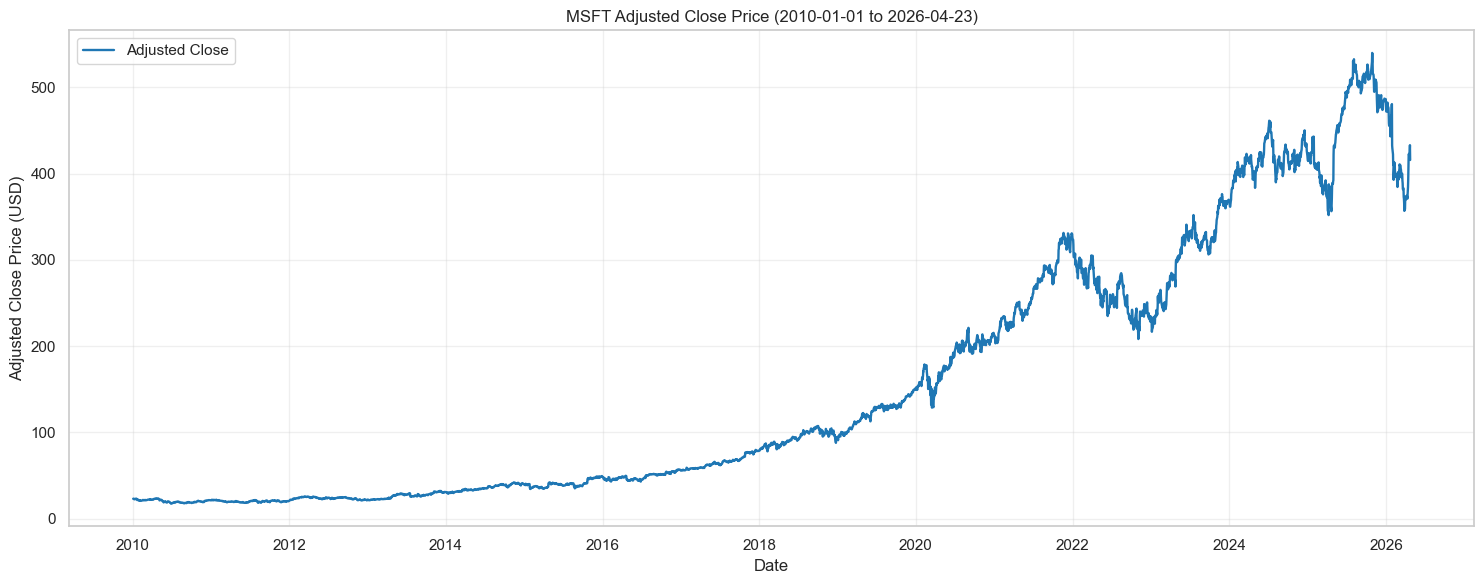

In [6]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df.index, df[TARGET_COL], label="Adjusted Close", color="#1f77b4", linewidth=1.7)
ax.set_title(f"MSFT Adjusted Close Price ({PROJECT_PERIOD_LABEL})")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "dataset_overview.png", dpi=150)
plt.show()


### Daily returns and volatility

Daily percentage returns help show that stock prices are non-stationary and volatility changes over time. This supports using chronological evaluation rather than random sampling.


Daily adjusted Close return summary (%):


,count,mean,std,min,25%,50%,75%,max
daily_return_pct,4100.0,0.083609,1.616666,-14.739017,-0.710598,0.06833,0.915188,14.216884


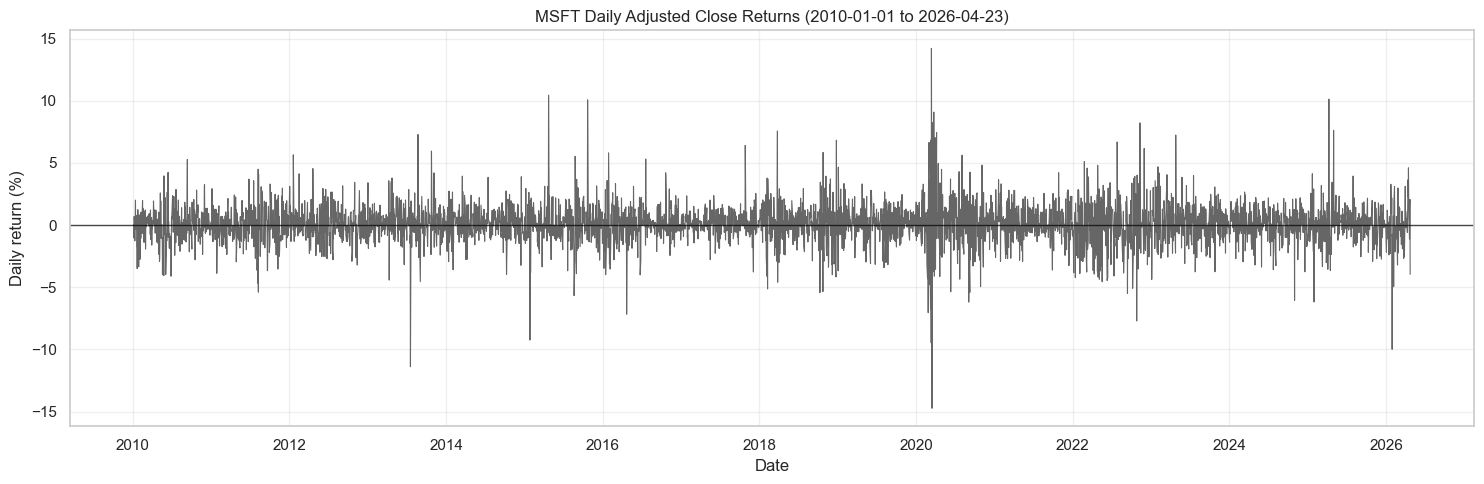

In [7]:
daily_returns = df[TARGET_COL].pct_change().dropna() * 100

print("Daily adjusted Close return summary (%):")
display(daily_returns.describe().to_frame("daily_return_pct").T)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily_returns.index, daily_returns, color="#666666", linewidth=0.8)
ax.axhline(0, color="black", linewidth=1, alpha=0.7)
ax.set_title(f"MSFT Daily Adjusted Close Returns ({PROJECT_PERIOD_LABEL})")
ax.set_xlabel("Date")
ax.set_ylabel("Daily return (%)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "daily_returns.png", dpi=150)
plt.show()


### Correlation between input features

The heatmap checks the pairwise relationships among the five input features used by the sequence models.


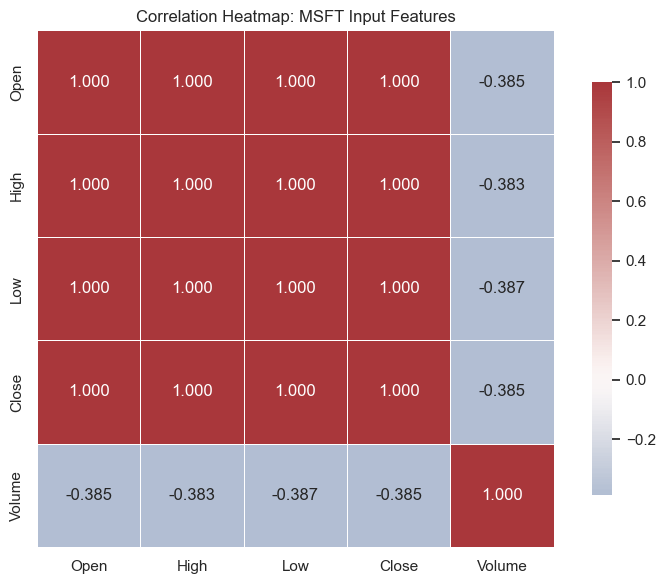

In [8]:
corr_matrix = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Correlation Heatmap: MSFT Input Features")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "feature_correlation_heatmap.png", dpi=150)
plt.show()


## Train-validation-test split

The data is split chronologically into 70% training, 15% validation, and 15% test data. The rows are not shuffled.

Chronological splitting is required for time-series forecasting because a model should only learn from information that would have been available before the forecast date. Random splitting would allow future market regimes to leak into training and validation samples, producing overly optimistic results.


In [9]:
# Chronological Train/Validation/Test Split (70/15/15)
n_rows = len(df)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

split_summary = pd.DataFrame(
    [
        {
            "Split": "Train",
            "Rows": len(train_df),
            "Start date": train_df.index.min().date(),
            "End date": train_df.index.max().date(),
        },
        {
            "Split": "Validation",
            "Rows": len(val_df),
            "Start date": val_df.index.min().date(),
            "End date": val_df.index.max().date(),
        },
        {
            "Split": "Test",
            "Rows": len(test_df),
            "Start date": test_df.index.min().date(),
            "End date": test_df.index.max().date(),
        },
    ]
)

print(f"Project period: {PROJECT_PERIOD_LABEL}")
print("Chronological split row counts and date ranges:")
display(split_summary)

assert len(train_df) + len(val_df) + len(test_df) == len(df)
assert train_df.index.max() < val_df.index.min() < test_df.index.min()
assert train_df.index.is_monotonic_increasing
assert val_df.index.is_monotonic_increasing
assert test_df.index.is_monotonic_increasing


Project period: 2010-01-01 to 2026-04-23
Chronological split row counts and date ranges:


,Split,Rows,Start date,End date
0,Train,2870,2010-01-04,2021-05-27
1,Validation,615,2021-05-28,2023-11-06
2,Test,616,2023-11-07,2026-04-23


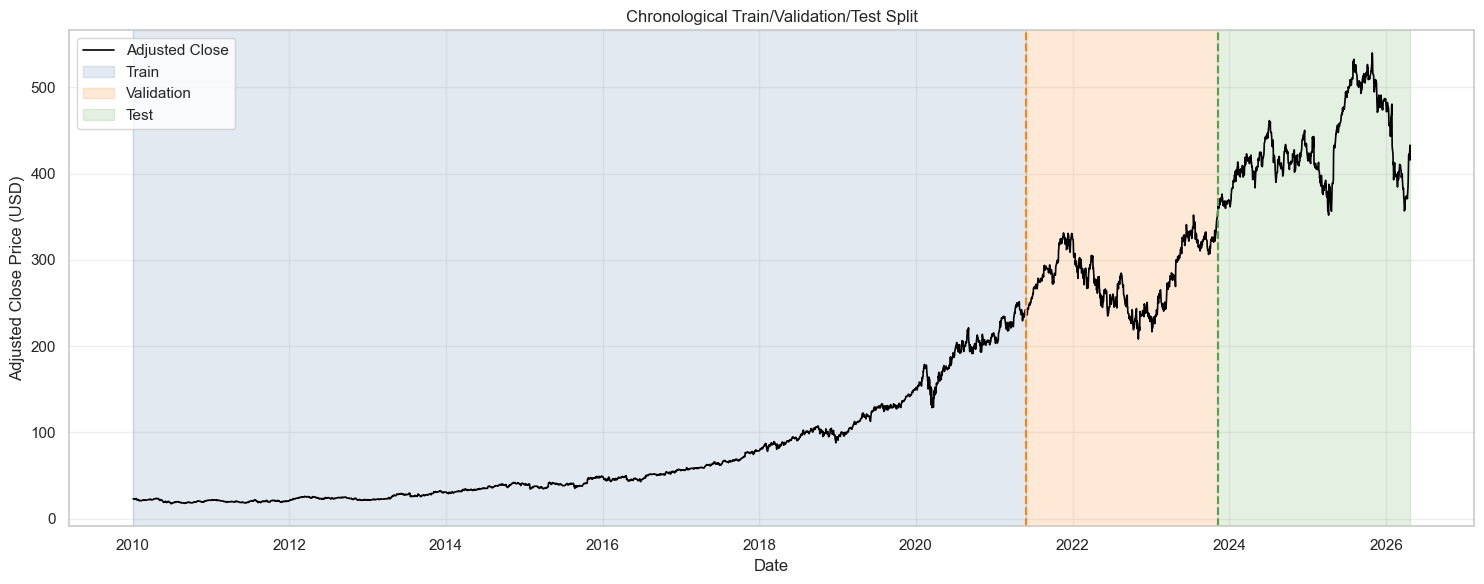

In [10]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df.index, df[TARGET_COL], color="black", linewidth=1.2, label="Adjusted Close")

ax.axvspan(train_df.index.min(), train_df.index.max(), alpha=0.16, color="#4c78a8", label="Train")
ax.axvspan(val_df.index.min(), val_df.index.max(), alpha=0.18, color="#f58518", label="Validation")
ax.axvspan(test_df.index.min(), test_df.index.max(), alpha=0.16, color="#54a24b", label="Test")

ax.axvline(val_df.index.min(), color="#f58518", linestyle="--", linewidth=1.5)
ax.axvline(test_df.index.min(), color="#54a24b", linestyle="--", linewidth=1.5)

ax.set_title("Chronological Train/Validation/Test Split")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close Price (USD)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "train_val_test_split.png", dpi=150)
plt.show()


### Split plot interpretation

The shaded plot is a visual check that train, validation, and test periods follow time order and do not overlap. This is important because random shuffling would let future market behaviour influence training and would make the test result too optimistic.


## Scaling strategy and leakage prevention

The feature scaler and target scaler are fitted only on the training split. Validation and test data are transformed with the training-fitted scalers.

This prevents data leakage: the model and preprocessing pipeline do not use future validation or test distribution information when preparing training data.


In [11]:
# Fit scalers only on training data.
scaler_all = MinMaxScaler(feature_range=(0, 1))
scaler_all.fit(train_df[FEATURE_COLS])

# Separate Close scaler is used by later notebooks for inverse transformation to dollar values.
scaler_close = MinMaxScaler(feature_range=(0, 1))
scaler_close.fit(train_df[[TARGET_COL]])

train_scaled = scaler_all.transform(train_df[FEATURE_COLS])
val_scaled = scaler_all.transform(val_df[FEATURE_COLS])
test_scaled = scaler_all.transform(test_df[FEATURE_COLS])

train_scaled_df = pd.DataFrame(train_scaled, index=train_df.index, columns=FEATURE_COLS)
val_scaled_df = pd.DataFrame(val_scaled, index=val_df.index, columns=FEATURE_COLS)
test_scaled_df = pd.DataFrame(test_scaled, index=test_df.index, columns=FEATURE_COLS)

print(f"Scaled train shape: {train_scaled.shape}")
print(f"Scaled validation shape: {val_scaled.shape}")
print(f"Scaled test shape: {test_scaled.shape}")
print("Feature scaler and target scaler fitted only on training data.")

assert not np.isnan(train_scaled).any()
assert not np.isnan(val_scaled).any()
assert not np.isnan(test_scaled).any()


Scaled train shape: (2870, 5)
Scaled validation shape: (615, 5)
Scaled test shape: (616, 5)
Feature scaler and target scaler fitted only on training data.


### Scaled range check

Because `MinMaxScaler` is fitted only on the training set, validation and test values may fall outside the `[0, 1]` range if later market prices or volumes exceed the historical training range. This is not an error or data leakage. Instead, it is useful evidence of non-stationarity and scale shift, which may help explain why some models struggle to generalise on the test period.


In [12]:
scaled_range_summary = pd.DataFrame(index=FEATURE_COLS)
for split_name, scaled_df in {
    "train": train_scaled_df,
    "val": val_scaled_df,
    "test": test_scaled_df,
}.items():
    scaled_range_summary[f"{split_name}_min"] = scaled_df[FEATURE_COLS].min()
    scaled_range_summary[f"{split_name}_max"] = scaled_df[FEATURE_COLS].max()

scaled_range_summary["val_outside_0_1"] = (
    (scaled_range_summary["val_min"] < 0) | (scaled_range_summary["val_max"] > 1)
)
scaled_range_summary["test_outside_0_1"] = (
    (scaled_range_summary["test_min"] < 0) | (scaled_range_summary["test_max"] > 1)
)

scaled_range_summary_csv_path = TABLES_DIR / "scaled_range_summary.csv"
scaled_range_summary.to_csv(scaled_range_summary_csv_path, index_label="Feature")

print("Scaled range summary by split:")
display(scaled_range_summary)

val_outside_features = scaled_range_summary.index[scaled_range_summary["val_outside_0_1"]].tolist()
test_outside_features = scaled_range_summary.index[scaled_range_summary["test_outside_0_1"]].tolist()

print(f"Validation features outside [0, 1]: {val_outside_features if val_outside_features else 'None'}")
print(f"Test features outside [0, 1]: {test_outside_features if test_outside_features else 'None'}")
print(f"Saved scaled range summary to: {scaled_range_summary_csv_path}")


Scaled range summary by split:


,train_min,train_max,val_min,val_max,test_min,test_max,val_outside_0_1,test_outside_0_1
Open,0.0,1.0,0.830178,1.441053,1.415638,2.287723,True,True
High,0.0,1.0,0.836692,1.453330,1.438530,2.275310,True,True
Low,0.0,1.0,0.818265,1.417185,1.397868,2.242267,True,True
Close,0.0,1.0,0.815467,1.429655,1.429335,2.232370,True,True
Volume,0.0,1.0,0.005692,0.266128,-0.005033,0.389332,False,True


Validation features outside [0, 1]: ['Open', 'High', 'Low', 'Close']
Test features outside [0, 1]: ['Open', 'High', 'Low', 'Close', 'Volume']
Saved scaled range summary to: ../outputs/tables/scaled_range_summary.csv


### Scaled range interpretation

The table shows the min and max scaled values by split. If validation or test values go outside `[0, 1]`, that is expected because the scaler was fitted only on the training period. For this project it is also useful evidence that later MSFT prices are in a different scale range from the earlier training data.


## Sequence/window creation

For LSTM and GRU compatibility, each sample uses a 60-day input window with shape `(60, 5)`. The target is the adjusted Close value on the next trading day after the final date in the input window.

Validation windows are allowed to use the final 60 training days as historical context, and test windows are allowed to use the final 60 validation days as historical context. This mirrors a real forecast setting because those historical values are known before the validation or test target dates.

This project evaluates one-step-ahead forecasting. For each target date, the previous 60 observed trading days are used as input, and the model predicts the next trading day's adjusted Close. This is different from recursive multi-step forecasting, where a model repeatedly feeds its own predictions back into future inputs.


In [13]:
def to_date_array(index):
    # Return a compact date array suitable for saving with NumPy.
    return pd.to_datetime(index).values.astype("datetime64[D]")


def create_sequences(data_scaled, date_index, target_col_idx=3, window_size=60):
    # Create overlapping supervised forecasting sequences.
    # X contains the previous `window_size` rows.
    # y contains the target Close value at the next row after each window.
    # target_dates contains the actual date of each y value.
    date_array = to_date_array(date_index)
    X, y, target_dates = [], [], []

    for i in range(window_size, len(data_scaled)):
        X.append(data_scaled[i - window_size : i])
        y.append(data_scaled[i, target_col_idx])
        target_dates.append(date_array[i])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32).reshape(-1)
    target_dates = np.array(target_dates, dtype="datetime64[D]")
    return X, y, target_dates


target_idx = FEATURE_COLS.index(TARGET_COL)

# Train sequences: target dates begin after the first 60 training rows.
X_train, y_train, train_dates = create_sequences(train_scaled, train_df.index, target_idx, WINDOW_SIZE)

# Validation sequences: prepend known training history, but targets remain validation dates.
val_input = np.vstack((train_scaled[-WINDOW_SIZE:], val_scaled))
val_input_dates = np.concatenate((to_date_array(train_df.index[-WINDOW_SIZE:]), to_date_array(val_df.index)))
X_val, y_val, val_dates = create_sequences(val_input, val_input_dates, target_idx, WINDOW_SIZE)

# Test sequences: prepend known validation history, but targets remain test dates.
test_input = np.vstack((val_scaled[-WINDOW_SIZE:], test_scaled))
test_input_dates = np.concatenate((to_date_array(val_df.index[-WINDOW_SIZE:]), to_date_array(test_df.index)))
X_test, y_test, test_dates = create_sequences(test_input, test_input_dates, target_idx, WINDOW_SIZE)

expected_train_dates = to_date_array(train_df.index[WINDOW_SIZE:])
expected_val_dates = to_date_array(val_df.index)
expected_test_dates = to_date_array(test_df.index)

np.testing.assert_array_equal(train_dates, expected_train_dates)
np.testing.assert_array_equal(val_dates, expected_val_dates)
np.testing.assert_array_equal(test_dates, expected_test_dates)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}, train_dates: {train_dates.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}, val_dates:   {val_dates.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}, test_dates:  {test_dates.shape}")

print(
    "First train sample: "
    f"window ends {train_df.index[WINDOW_SIZE - 1].date()} -> target {pd.Timestamp(train_dates[0]).date()}"
)
print(
    "Last test sample: "
    f"window ends {pd.Timestamp(test_input_dates[-2]).date()} -> target {pd.Timestamp(test_dates[-1]).date()}"
)


X_train: (2810, 60, 5), y_train: (2810,), train_dates: (2810,)
X_val:   (615, 60, 5), y_val:   (615,), val_dates:   (615,)
X_test:  (616, 60, 5), y_test:  (616,), test_dates:  (616,)
First train sample: window ends 2010-03-30 -> target 2010-03-31
Last test sample: window ends 2026-04-22 -> target 2026-04-23


### Sequence validation and leakage checks

The checks below verify that the generated arrays remain compatible with the later modelling notebooks and that the saved dates match the actual target Close dates represented by `y_train`, `y_val`, and `y_test`.


In [14]:
def assert_sequence_outputs(name, X, y, dates, expected_dates, scaled_df):
    assert X.ndim == 3, f"{name} X must be 3D. Found shape {X.shape}."
    assert X.shape[1:] == (WINDOW_SIZE, len(FEATURE_COLS)), f"{name} X has unexpected feature/window shape."
    assert y.ndim == 1, f"{name} y must be 1D. Found shape {y.shape}."
    assert len(X) == len(y) == len(dates), f"{name} X, y, and dates lengths do not match."
    assert len(dates) == len(expected_dates), f"{name} date count differs from expected target dates."
    np.testing.assert_array_equal(dates, expected_dates)

    pd_dates = pd.to_datetime(dates)
    assert pd_dates.is_monotonic_increasing, f"{name} target dates are not chronological."
    assert pd_dates.is_unique, f"{name} target dates are not unique."

    target_values_from_source = scaled_df.loc[pd_dates, TARGET_COL].to_numpy(dtype=np.float32)
    np.testing.assert_allclose(
        y,
        target_values_from_source,
        rtol=1e-6,
        atol=1e-6,
        err_msg=f"{name} y values do not align with their saved target dates.",
    )

    assert not np.isnan(X).any(), f"{name} X contains NaNs."
    assert not np.isnan(y).any(), f"{name} y contains NaNs."


assert df.index.is_monotonic_increasing
assert train_df.index.max() < val_df.index.min() < test_df.index.min()
assert not df[FEATURE_COLS].isna().any().any()

assert_sequence_outputs("Train", X_train, y_train, train_dates, expected_train_dates, train_scaled_df)
assert_sequence_outputs("Validation", X_val, y_val, val_dates, expected_val_dates, val_scaled_df)
assert_sequence_outputs("Test", X_test, y_test, test_dates, expected_test_dates, test_scaled_df)

print("Chronological order confirmed for train, validation, and test sets.")
print("No NaNs remain after preprocessing.")
print("Feature arrays and target arrays have matching sample counts.")
print("X arrays are 3D with shape (samples, 60, 5); y arrays are 1D.")
print("Saved target dates align with the actual Close target values used in y arrays.")


Chronological order confirmed for train, validation, and test sets.
No NaNs remain after preprocessing.
Feature arrays and target arrays have matching sample counts.
X arrays are 3D with shape (samples, 60, 5); y arrays are 1D.
Saved target dates align with the actual Close target values used in y arrays.


## Saved outputs for modelling notebooks

The existing NumPy arrays and scalers are saved with the same filenames expected by the later notebooks. Additional date arrays are saved so comparison and reporting notebooks can align predictions with the exact trading dates represented by each target value.

The saved multivariate NumPy arrays are used directly by the LSTM and GRU notebooks. The PatchTST notebook may prepare its own NeuralForecast dataframe depending on the library interface, but it should use the same project date range and adjusted Close target for fair comparison.


In [15]:
# Save processed arrays for downstream modelling notebooks.
output_paths = {
    "X_train": DATA_DIR / "X_train.npy",
    "y_train": DATA_DIR / "y_train.npy",
    "X_val": DATA_DIR / "X_val.npy",
    "y_val": DATA_DIR / "y_val.npy",
    "X_test": DATA_DIR / "X_test.npy",
    "y_test": DATA_DIR / "y_test.npy",
    "train_dates": DATA_DIR / "train_dates.npy",
    "val_dates": DATA_DIR / "val_dates.npy",
    "test_dates": DATA_DIR / "test_dates.npy",
    "scaler_all": MODELS_DIR / "scaler_all.pkl",
    "scaler_close": MODELS_DIR / "scaler_close.pkl",
}

np.save(output_paths["X_train"], X_train)
np.save(output_paths["y_train"], y_train)
np.save(output_paths["X_val"], X_val)
np.save(output_paths["y_val"], y_val)
np.save(output_paths["X_test"], X_test)
np.save(output_paths["y_test"], y_test)
np.save(output_paths["train_dates"], train_dates.astype("datetime64[D]"))
np.save(output_paths["val_dates"], val_dates.astype("datetime64[D]"))
np.save(output_paths["test_dates"], test_dates.astype("datetime64[D]"))

joblib.dump(scaler_all, output_paths["scaler_all"])
joblib.dump(scaler_close, output_paths["scaler_close"])

print("Saved preprocessing outputs:")
for name, path in output_paths.items():
    print(f"- {name}: {path}")


Saved preprocessing outputs:
- X_train: ../data/X_train.npy
- y_train: ../data/y_train.npy
- X_val: ../data/X_val.npy
- y_val: ../data/y_val.npy
- X_test: ../data/X_test.npy
- y_test: ../data/y_test.npy
- train_dates: ../data/train_dates.npy
- val_dates: ../data/val_dates.npy
- test_dates: ../data/test_dates.npy
- scaler_all: ../models/scaler_all.pkl
- scaler_close: ../models/scaler_close.pkl


## Final validation summary

This final cell reports the modelling interface that later notebooks should expect from Notebook 01.


In [16]:
final_split_summary = pd.DataFrame(
    [
        {
            "Split": "Train",
            "Raw rows": len(train_df),
            "Windowed samples": len(y_train),
            "Raw start": train_df.index.min().date(),
            "Raw end": train_df.index.max().date(),
            "Target start": pd.Timestamp(train_dates[0]).date(),
            "Target end": pd.Timestamp(train_dates[-1]).date(),
        },
        {
            "Split": "Validation",
            "Raw rows": len(val_df),
            "Windowed samples": len(y_val),
            "Raw start": val_df.index.min().date(),
            "Raw end": val_df.index.max().date(),
            "Target start": pd.Timestamp(val_dates[0]).date(),
            "Target end": pd.Timestamp(val_dates[-1]).date(),
        },
        {
            "Split": "Test",
            "Raw rows": len(test_df),
            "Windowed samples": len(y_test),
            "Raw start": test_df.index.min().date(),
            "Raw end": test_df.index.max().date(),
            "Target start": pd.Timestamp(test_dates[0]).date(),
            "Target end": pd.Timestamp(test_dates[-1]).date(),
        },
    ]
)

val_scaled_outside_features = scaled_range_summary.index[scaled_range_summary["val_outside_0_1"]].tolist()
test_scaled_outside_features = scaled_range_summary.index[scaled_range_summary["test_outside_0_1"]].tolist()

print("Final validation summary")
print(f"Project period: {PROJECT_PERIOD_LABEL}")
print(f"Feature columns used: {FEATURE_COLS}")
print(f"Target column: next trading-day adjusted {TARGET_COL}")
print(f"Window size: {WINDOW_SIZE} trading days")
print("Train/validation/test sample counts and date ranges:")
display(final_split_summary)

print("Saved output paths:")
for name, path in output_paths.items():
    print(f"- {path}")
print(f"- {scaled_range_summary_csv_path}")

print(
    "Scaled validation features outside the training-fitted [0, 1] range: "
    f"{val_scaled_outside_features if val_scaled_outside_features else 'None'}"
)
print(
    "Scaled test features outside the training-fitted [0, 1] range: "
    f"{test_scaled_outside_features if test_scaled_outside_features else 'None'}"
)
print(f"Scaled range summary CSV saved to {scaled_range_summary_csv_path}.")

print("Notebook 01 completed successfully.")
print(
    "Important: because Notebook 01 may regenerate arrays with a slightly different test length, "
    "all old outputs from notebooks 02, 03, and 04, including saved predictions, metrics CSVs, "
    "plots, and model checkpoints, should be treated as stale until those notebooks are rerun later."
)


Final validation summary
Project period: 2010-01-01 to 2026-04-23
Feature columns used: ['Open', 'High', 'Low', 'Close', 'Volume']
Target column: next trading-day adjusted Close
Window size: 60 trading days
Train/validation/test sample counts and date ranges:


,Split,Raw rows,Windowed samples,Raw start,Raw end,Target start,Target end
0,Train,2870,2810,2010-01-04,2021-05-27,2010-03-31,2021-05-27
1,Validation,615,615,2021-05-28,2023-11-06,2021-05-28,2023-11-06
2,Test,616,616,2023-11-07,2026-04-23,2023-11-07,2026-04-23


Saved output paths:
- ../data/X_train.npy
- ../data/y_train.npy
- ../data/X_val.npy
- ../data/y_val.npy
- ../data/X_test.npy
- ../data/y_test.npy
- ../data/train_dates.npy
- ../data/val_dates.npy
- ../data/test_dates.npy
- ../models/scaler_all.pkl
- ../models/scaler_close.pkl
- ../outputs/tables/scaled_range_summary.csv
Scaled validation features outside the training-fitted [0, 1] range: ['Open', 'High', 'Low', 'Close']
Scaled test features outside the training-fitted [0, 1] range: ['Open', 'High', 'Low', 'Close', 'Volume']
Scaled range summary CSV saved to ../outputs/tables/scaled_range_summary.csv.
Notebook 01 completed successfully.
Important: because Notebook 01 may regenerate arrays with a slightly different test length, all old outputs from notebooks 02, 03, and 04, including saved predictions, metrics CSVs, plots, and model checkpoints, should be treated as stale until those notebooks are rerun later.


## Notebook 01 summary

This notebook produced the cleaned MSFT OHLCV dataset, chronological train/validation/test splits, training-fitted scalers, and 60-day supervised windows for next-day Close forecasting.

Saved outputs include:

- `X_train.npy`, `X_val.npy`, `X_test.npy`
- `y_train.npy`, `y_val.npy`, `y_test.npy`
- target-date arrays for alignment
- `scaler_all.pkl` and `scaler_close.pkl`
- preprocessing plots and summary tables

Notebook 02 uses the saved arrays and scaler for LSTM/GRU modelling. Notebook 03 keeps the same date range and target definition for PatchTST. Notebook 04 uses the saved prediction outputs from the modelling notebooks for final comparison.
